## EN3160 Assignment 1
### Intensity Transformations and Neighborhood Filtering

- Name : Ahamed A.M.S
- Index No : 230020R
- GitHub : https://github.com/shaahidahamed (https://github.com/shaahidahamed/EN3160-Image-Processing-and-Machine-Vision/tree/main/Assignments/Assignment-1)

<img src="Q1.png" />

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

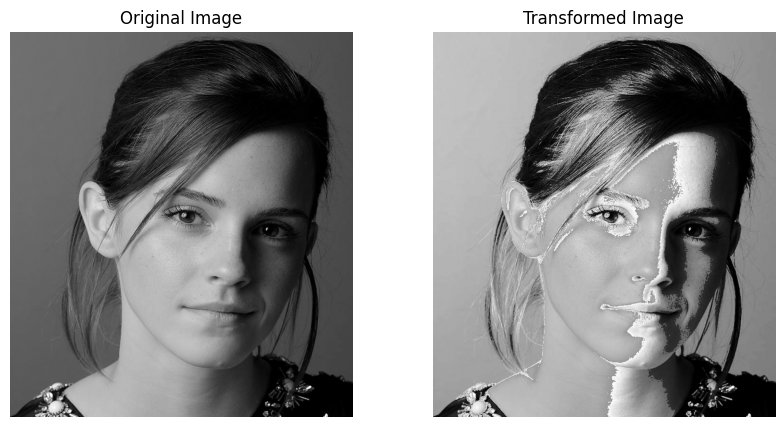

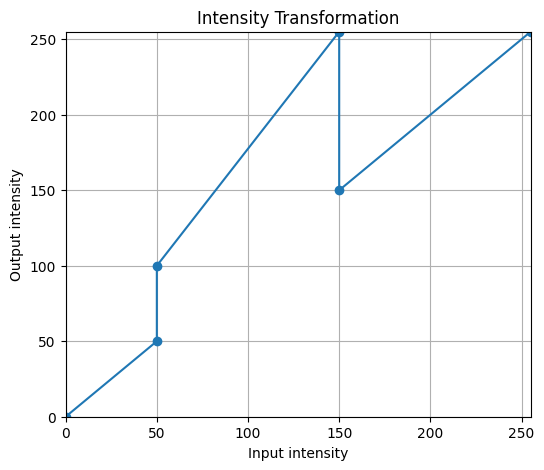

In [4]:
img = cv.imread('./images/emma.jpg', cv.IMREAD_GRAYSCALE)

def intensity_transform(im, breakpoints):
    breakpoints = np.asarray(breakpoints)

    x = breakpoints[:, 0]
    y = breakpoints[:, 1]

    transformed = np.interp(im, x, y)

    return np.clip(transformed, 0, 255).astype(np.uint8)

breakpoints = np.array([
    [0,   0],[50,  50],[50,  100],
    [150, 255],[150, 150],[255, 255]])

result = intensity_transform(img, breakpoints)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Transformed Image')
plt.imshow(result, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(breakpoints[:, 0],breakpoints[:, 1],marker='o')
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Intensity Transformation")
plt.grid()
plt.show()


**Discussion:**

<img src="Q2.png" />

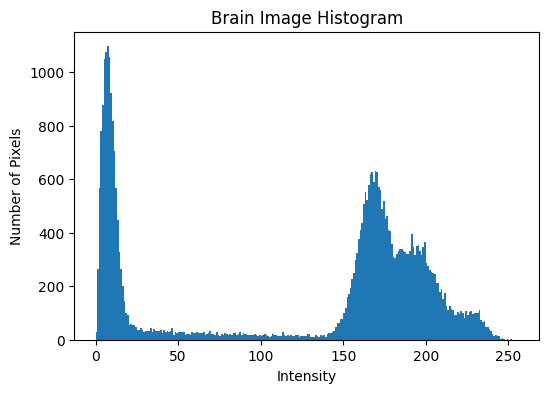

In [5]:
brain = cv.imread('./images/brain_proton_density_slice.png', cv.IMREAD_GRAYSCALE)

plt.figure(figsize=(6, 4))
plt.hist(brain.ravel(), bins=256, range=(0, 256))
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")
plt.title("Brain Image Histogram")
plt.show()

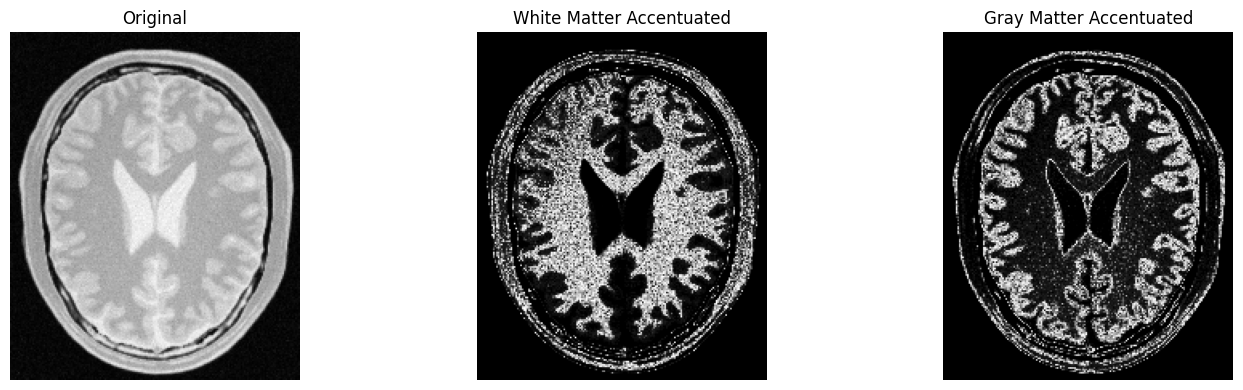

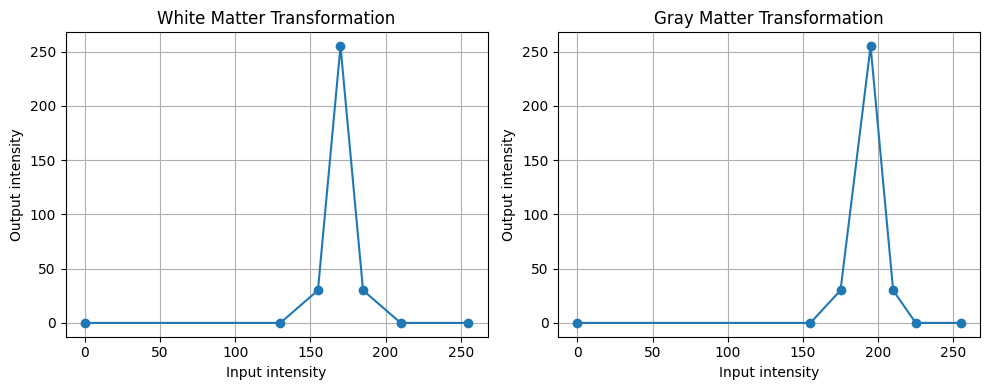

In [6]:
white_bp = np.array([
    [0,   0],[130, 0],[155, 30],[170, 255],
    [185, 30],[210, 0],[255, 0]])

white_matter = intensity_transform(brain, white_bp)

gray_bp = np.array([
    [0,   0],[155, 0],[175, 30],[195, 255],
    [210, 30],[225, 0],[255, 0]])

gray_matter = intensity_transform(brain, gray_bp)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(brain, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(white_matter, cmap="gray")
plt.title("White Matter Accentuated")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gray_matter, cmap="gray")
plt.title("Gray Matter Accentuated")
plt.axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(white_bp[:,0], white_bp[:,1], marker='o')
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("White Matter Transformation")
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(gray_bp[:,0], gray_bp[:,1], marker='o')
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Gray Matter Transformation")
plt.grid()

plt.tight_layout()
plt.show()

<img src="Q3.png" />

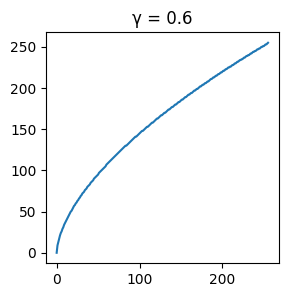

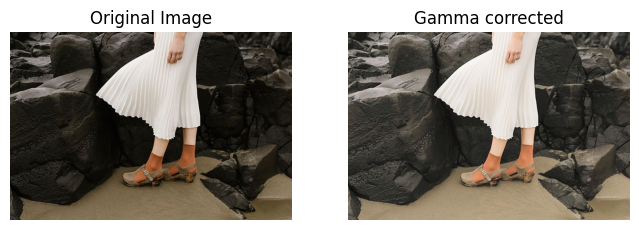

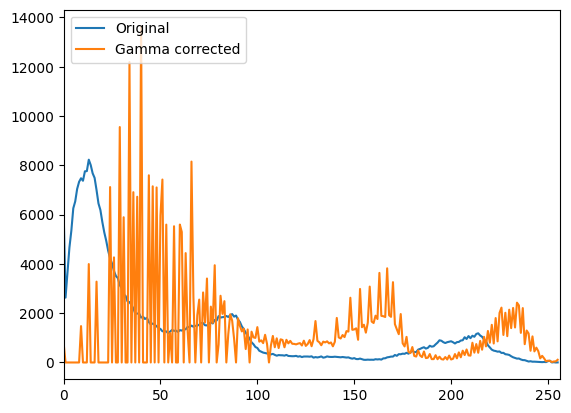

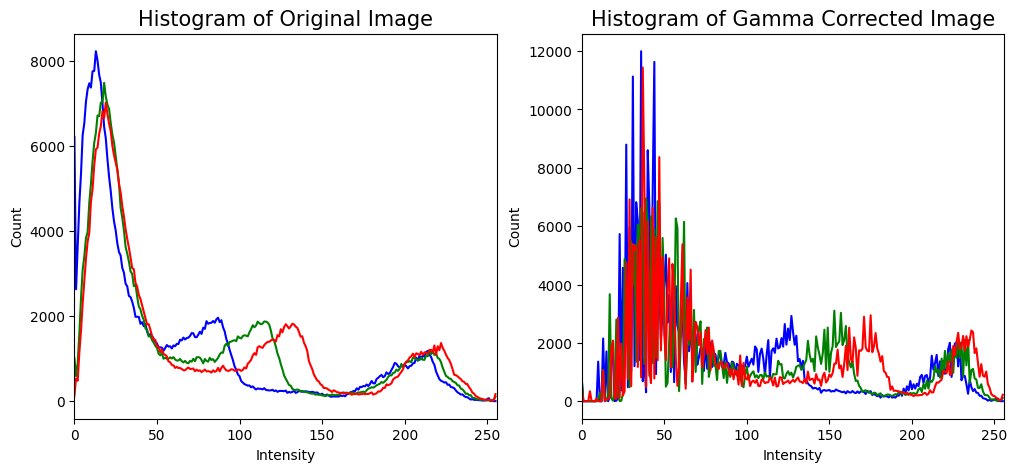

In [7]:
img = cv.imread('./images/highlights_and_shadows.jpg')
lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
L, a, b = cv.split(lab)
gamma = 0.6
t = np.array([(i / 255) ** gamma * 255 for i in range(0, 256)]).astype(np.uint8)
lab[:, :, 0] = t[lab[:, :, 0]]
g = cv.LUT(L, t)
corrected = cv.merge([g, a, b])
hist1 = cv.calcHist([img], [0], None, [256], [0, 256])
hist2 = cv.calcHist([corrected], [0], None, [256], [0, 256])

def histBGR(img):
    colors = ['b', 'g', 'r']
    for i in range(3):
        hist = cv.calcHist([img], [i], None, [256], [0, 256])
        plt.plot(hist, color=colors[i])
    plt.xlim(0, 256)

fig, ax = plt.subplots(figsize=(3, 3))
ax.set_title(f"\u03B3 = {gamma}")
ax.plot(t)

fig, ax = plt.subplots(1, 2, figsize=(8, 8))

ax[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(cv.cvtColor(corrected, cv.COLOR_LAB2RGB))
ax[1].set_title('Gamma corrected')
ax[1].axis('off') 

plt.show()

plt.plot(hist1)  
plt.xlim([0, 256])  

plt.plot(hist2)
plt.xlim([0, 256])

plt.legend(('Original', 'Gamma corrected'), loc='upper left')

plt.show()

plt.figure(figsize=(12, 5)) 
plt.rc('axes', titlesize=15)  

plt.subplot(121)  
histBGR(img)  
plt.title("Histogram of Original Image")
plt.xlabel("Intensity")  
plt.ylabel("Count")  

plt.subplot(122)  
histBGR(cv.cvtColor(lab, cv.COLOR_LAB2BGR))  
plt.title("Histogram of Gamma Corrected Image")
plt.xlabel("Intensity")  
plt.ylabel("Count")  

plt.show()

<img src="Q4.png" />

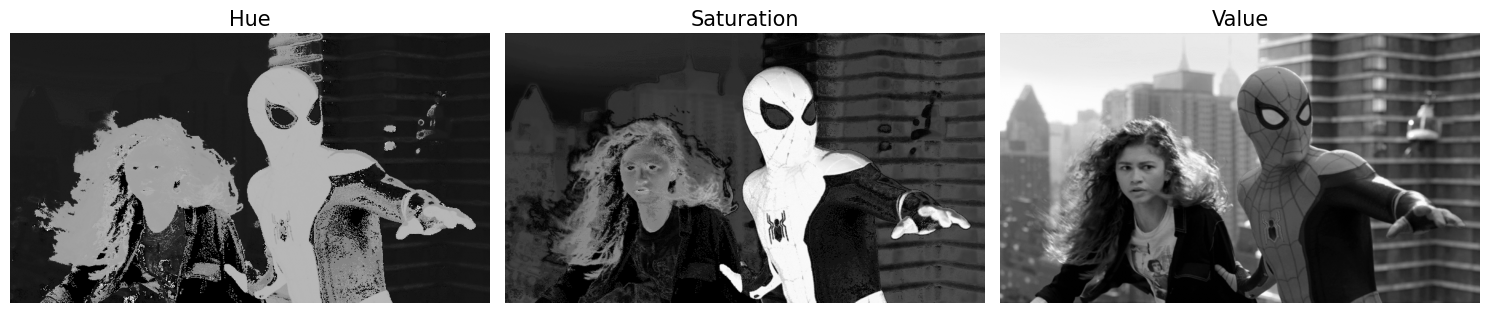

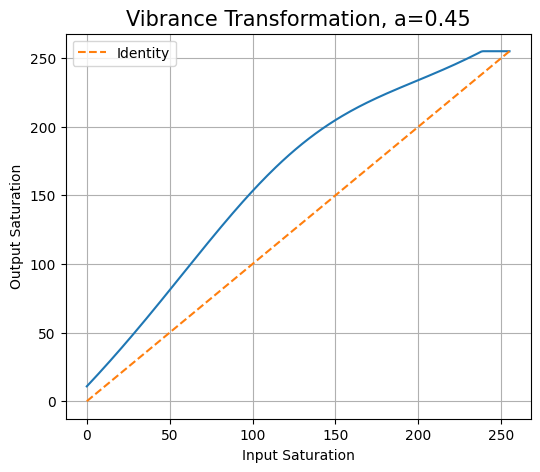

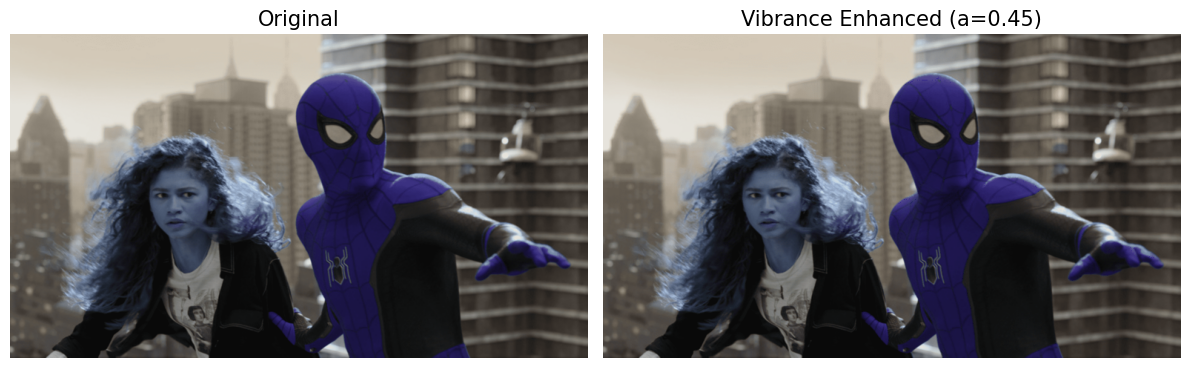

In [ ]:
img = cv.imread('./images/spider.png', cv.IMREAD_COLOR)
hsv = cv.cvtColor(img, cv.COLOR_RGB2HSV)
H, S, V = cv.split(hsv)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(H, cmap="gray")
plt.title("Hue")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(S, cmap="gray")
plt.title("Saturation")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(V, cmap="gray")
plt.title("Value")
plt.axis("off")

plt.tight_layout()
plt.show()

def vibrance_transform(S, a, sigma=70):
    x = S.astype(np.float32)
    enhancement = (a * 128 *np.exp(-((x - 128) ** 2) /2 * sigma ** 2))
    result = np.minimum(x + enhancement,255)
    return result.astype(np.uint8)

a_value = 0.45

S_new = vibrance_transform(S,a=a_value)
hsv_new = cv.merge([H, S_new, V])
vibrant = cv.cvtColor(hsv_new,cv.COLOR_HSV2RGB)

x = np.arange(256)
y = np.minimum(x + a_value * 128 *np.exp(-((x - 128) ** 2) /(2 * 70 ** 2)),255)



plt.figure(figsize=(6, 5))
plt.plot(x, y)
plt.plot(x, x, '--', label="Identity")
plt.xlabel("Input Saturation")
plt.ylabel("Output Saturation")
plt.title(f"Vibrance Transformation, a={a_value}")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(vibrant)
plt.title(f"Vibrance Enhanced (a={a_value})")
plt.axis("off")

plt.tight_layout()
plt.show()


<img src="Q5.png" />

<img src="Q6.png" />

<img src="Q7.png" />

<img src="Q8.png" />

<img src="Q9.png" />

<img src="Q10.png" />